<a href="https://colab.research.google.com/github/norayyh/AutoInsight-R/blob/main/autoinsight.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
!pip install anthropic pandas matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 662.1/662.1 kB 24.1 MB/s eta 0:00:00


In [4]:
# Upload datasets to Colab from GitHub
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/Iris.csv -O Iris.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/titanic.csv -O titanic.csv
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/datasets/housing.csv -O housing.csv
print("Datasets downloaded successfully")

Datasets downloaded successfully


In [5]:
# Install the Anthropic library
import anthropic
from google.colab import userdata

# Initialize the client using the secret API key
client = anthropic.Anthropic(api_key=userdata.get("ANTHROPIC_API_KEY"))

# Send a test request to verify the API connection
response = client.messages.create(
    model="claude-sonnet-4-6",
    max_tokens=1024,
    messages=[
        {"role": "user", "content": "Write Python code using pandas to read iris.csv and print the first 5 rows"}
    ]
)

print(response.content[0].text)

## Reading Iris Dataset with Pandas

```python
import pandas as pd

# Read the CSV file
df = pd.read_csv('iris.csv')

# Print the first 5 rows
print(df.head())
```

### Sample Output
```
   sepal_length  sepal_width  petal_length  petal_width species
0           5.1          3.5           1.4          0.2  setosa
1           4.9          3.0           1.4          0.2  setosa
2           4.7          3.2           1.3          0.2  setosa
3           4.6          3.1           1.5          0.2  setosa
4           5.0          3.6           1.4          0.2  setosa
```

---

### Alternative: Load directly from a URL
If you don't have the file locally, you can load it directly:

```python
import pandas as pd

# Load Iris dataset from URL
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/iris.csv"
df = pd.read_csv(url)

# Print the first 5 rows
print(df.head())
```

---

### Alternative: Load from scikit-learn
```python
import pandas as pd
from sklearn.datasets import l

In [6]:
import traceback

def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()

# Test the executor with a simple example
test_code = "print('Executor is working!')"
success, message = execute_code(test_code)
print(message)

Executor is working!
Code executed successfully


In [7]:
import re

def clean_code(code: str) -> str:
    """
    Remove markdown code block formatting from generated code.
    """
    code = re.sub(r"```python\n", "", code)
    code = re.sub(r"```", "", code)
    return code.strip()


def generate_code(user_request: str, dataset_path: str) -> str:
    """
    Send a request to Claude to generate Python code for data analysis.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
Write Python code to complete the following task: {user_request}
Only return the Python code, no explanations or markdown formatting.
Only use these libraries: pandas, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def repair_code(user_request: str, previous_code: str, error_message: str, dataset_path: str) -> str:
    """
    Send the failed code and error message back to Claude for repair.
    """
    prompt = f"""You are a data analysis assistant.
The dataset is located at: {dataset_path}
The user request was: {user_request}

The following code was generated but failed:
{previous_code}

The error message was:
{error_message}

Please fix the code. Only return the corrected Python code, no explanations or markdown formatting.
Only use these libraries: pandas, matplotlib, seaborn, sklearn.
"""
    response = client.messages.create(
        model="claude-sonnet-4-6",
        max_tokens=1024,
        messages=[{"role": "user", "content": prompt}]
    )
    return response.content[0].text


def execute_code(code: str) -> tuple[bool, str]:
    """
    Execute the generated Python code and capture the result or error.
    Returns (success, message).
    """
    try:
        exec(code, {})
        return True, "Code executed successfully"
    except Exception as e:
        return False, traceback.format_exc()


def run_pipeline(user_request: str, dataset_path: str, max_retries: int = 3) -> dict:
    """
    Run the full self-healing pipeline:
    generate code -> execute -> repair if failed -> retry.
    If successful, print the result and final code.
    If all attempts fail, print the error and failed code.
    """
    code = clean_code(generate_code(user_request, dataset_path))

    for attempt in range(max_retries):
        success, message = execute_code(code)

        if success:
            print(f"Success on attempt {attempt + 1}")
            print("\n----- Final Code -----")
            print(code)
            return {"success": True, "attempts": attempt + 1, "code": code}

        print(f"Attempt {attempt + 1} failed.")
        print("----- Error Message -----")
        print(message)

        if attempt < max_retries - 1:
            code = clean_code(repair_code(user_request, code, message, dataset_path))

    print("\n----- All attempts failed -----")
    print("----- Final Failed Code -----")
    print(code)
    return {"success": False, "attempts": max_retries, "code": code, "error": message}


# Test the pipeline with an easy task
result = run_pipeline(
    user_request="Calculate the mean, standard deviation, max, and min for each numeric feature",
    dataset_path="Iris.csv"
)
print(result)

              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean   75.500000       5.843333      3.054000       3.758667      1.198667
std    43.445368       0.828066      0.433594       1.764420      0.763161
max   150.000000       7.900000      4.400000       6.900000      2.500000
min     1.000000       4.300000      2.000000       1.000000      0.100000
Success on attempt 1

----- Final Code -----
import pandas as pd

df = pd.read_csv('Iris.csv')

numeric_df = df.select_dtypes(include='number')

stats = numeric_df.agg(['mean', 'std', 'max', 'min'])

print(stats)
{'success': True, 'attempts': 1, 'code': "import pandas as pd\n\ndf = pd.read_csv('Iris.csv')\n\nnumeric_df = df.select_dtypes(include='number')\n\nstats = numeric_df.agg(['mean', 'std', 'max', 'min'])\n\nprint(stats)"}


In [8]:
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
!mkdir -p benchmarks
!wget -q https://raw.githubusercontent.com/norayyh/AutoInsight-R/main/benchmarks/prompts.json -O benchmarks/prompts.json
print("Datasets and benchmarks downloaded successfully")

benchmarks/prompts.json: No such file or directory
Datasets and benchmarks downloaded successfully



Running task 1: [easy] Calculate the mean, standard deviation, max, and min for each numeric feature
              Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm
mean   75.500000       5.843333      3.054000       3.758667      1.198667
std    43.445368       0.828066      0.433594       1.764420      0.763161
max   150.000000       7.900000      4.400000       6.900000      2.500000
min     1.000000       4.300000      2.000000       1.000000      0.100000
Success on attempt 1

----- Final Code -----
import pandas as pd

df = pd.read_csv('Iris.csv')

numeric_df = df.select_dtypes(include='number')

stats = numeric_df.agg(['mean', 'std', 'max', 'min'])

print(stats)
Result: Success | Attempts: 1

Running task 2: [easy] Plot a histogram for each of the four numeric features


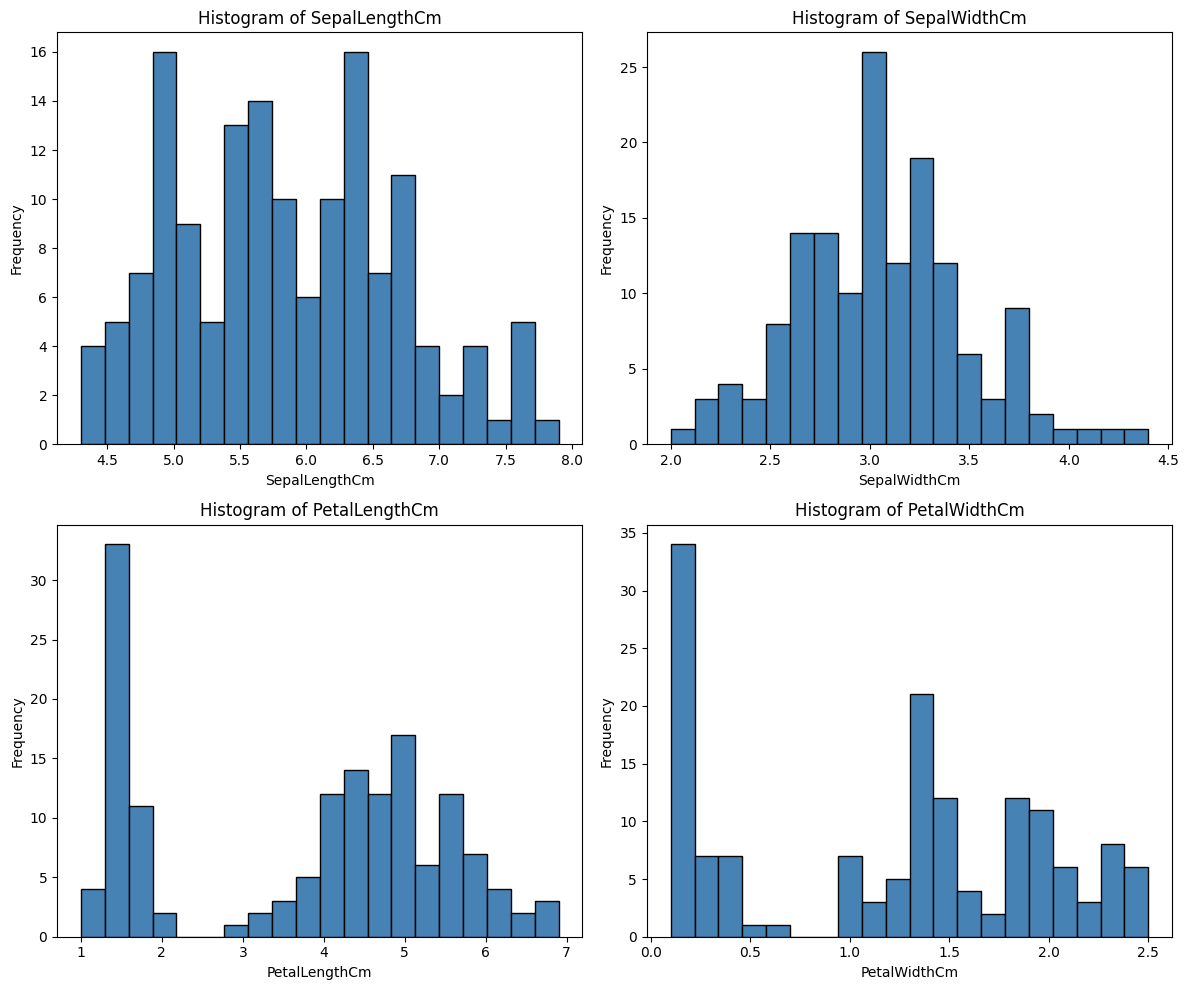

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Iris.csv')

numeric_features = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, feature in enumerate(numeric_features):
    axes[i].hist(df[feature], bins=20, color='steelblue', edgecolor='black')
    axes[i].set_title(f'Histogram of {feature}')
    axes[i].set_xlabel(feature)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()
Result: Success | Attempts: 1

Running task 3: [medium] Plot a boxplot of the length column grouped by species


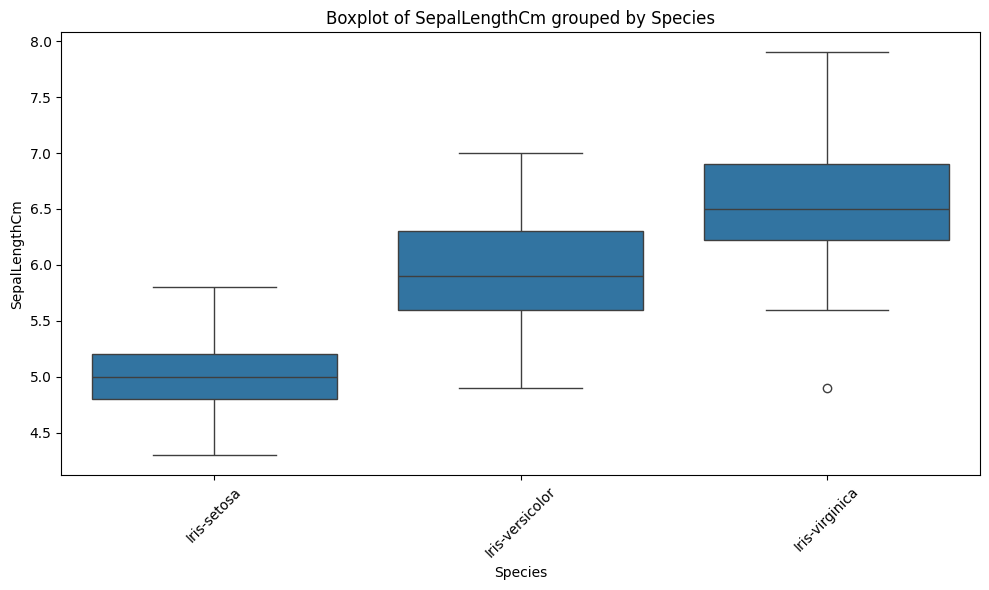

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Iris.csv')

# Find the length column (case-insensitive search)
length_col = None
for col in df.columns:
    if 'length' in col.lower():
        length_col = col
        break

# Find the species column
species_col = None
for col in df.columns:
    if 'species' in col.lower():
        species_col = col
        break

if length_col and species_col:
    plt.figure(figsize=(10, 6))
    sns.boxplot(x=species_col, y=length_col, data=df)
    plt.title(f'Boxplot of {length_col} grouped by {species_col}')
    plt.xlabel(species_col)
    plt.ylabel(length_col)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    # If no single length column, plot all length columns
    length_cols = [col for col in df.columns if 'length' in col.lower()]
    if length_cols and species_col:
        fig, axes = plt.subplots(1, len(length_cols), figsize=(6*l

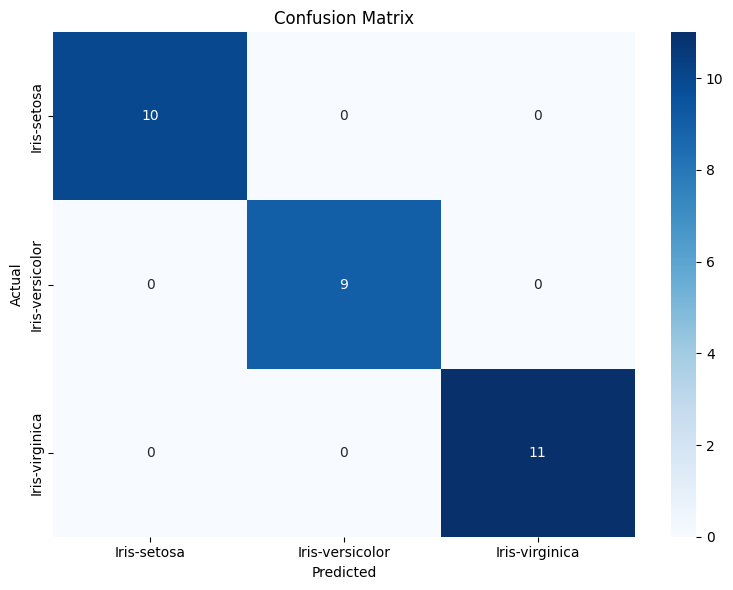

Success on attempt 1

----- Final Code -----
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset
df = pd.read_csv('Iris.csv')

# Encode the species column
le = LabelEncoder()
df['Species'] = le.fit_transform(df['Species'])

# Split the data into features and target
X = df.drop(columns=['Species'])
y = df['Species']

# Remove 'Id' column if it exists
if 'Id' in X.columns:
    X = X.drop(columns=['Id'])

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train the KNN classifier
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# Make predictions
y_pred = knn.predict(X_test)

# Calculate accuracy
accuracy = accuracy_score(y_test, y

<string>:10: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Attempt 1 failed.
----- Error Message -----
Traceback (most recent call last):
  File "/tmp/ipykernel_5492/3353569602.py", line 61, in execute_code
    exec(code, {})
  File "<string>", line 7, in <module>
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/frame.py", line 9183, in groupby
    return DataFrameGroupBy(
           ^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/groupby/groupby.py", line 1329, in __init__
    grouper, exclusions, obj = get_grouper(
                               ^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pandas/core/groupby/grouper.py", line 1043, in get_grouper
    raise KeyError(gpr)
KeyError: 'Survived'

['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']
   Passenge

<string>:19: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




Dataset shape: (1309, 28)

Column names: ['Passengerid', 'Age', 'Fare', 'Sex', 'sibsp', 'zero', 'zero.1', 'zero.2', 'zero.3', 'zero.4', 'zero.5', 'zero.6', 'Parch', 'zero.7', 'zero.8', 'zero.9', 'zero.10', 'zero.11', 'zero.12', 'zero.13', 'zero.14', 'Pclass', 'zero.15', 'zero.16', 'Embarked', 'zero.17', 'zero.18', '2urvived']

Missing values before cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0
zero.2         0
zero.3         0
zero.4         0
zero.5         0
zero.6         0
Parch          0
zero.7         0
zero.8         0
zero.9         0
zero.10        0
zero.11        0
zero.12        0
zero.13        0
zero.14        0
Pclass         0
zero.15        0
zero.16        0
Embarked       2
zero.17        0
zero.18        0
2urvived       0
dtype: int64

Missing values after cleaning:
Passengerid    0
Age            0
Fare           0
Sex            0
sibsp          0
zero           0
zero.1         0

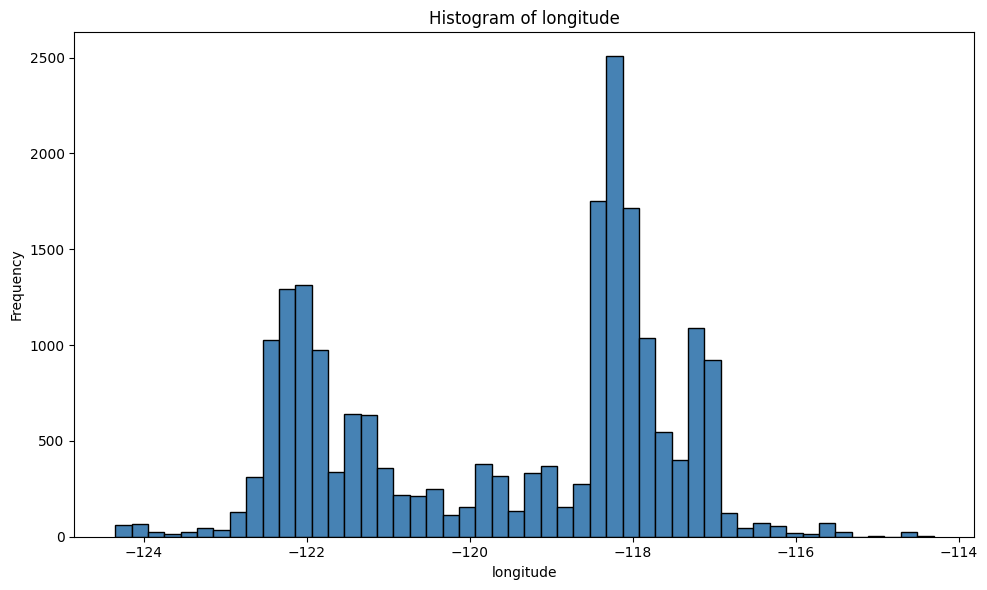

Histogram saved as 'house_price_histogram.png'
Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

print(df.columns.tolist())
print(df.head())

# Identify the price column
price_col = None
for col in df.columns:
    if 'price' in col.lower():
        price_col = col
        break

if price_col is None:
    # Try to find a column that might represent price
    numeric_cols = df.select_dtypes(include='number').columns.tolist()
    print(f"No price column found. Available numeric columns: {numeric_cols}")
    price_col = numeric_cols[0]  # Use first numeric column as fallback
    print(f"Using '{price_col}' as the price column.")

plt.figure(figsize=(10, 6))
plt.hist(df[price_col].dropna(), bins=50, color='steelblue', edgecolor='black')
plt.title(f'Histogram of {price_col}')
plt.xlabel(price_col)
plt.ylabel('Frequency')
plt.tight_layout()
plt.savefig('house_price_histogram.png', dpi=150)
plt.show()
print("Histo

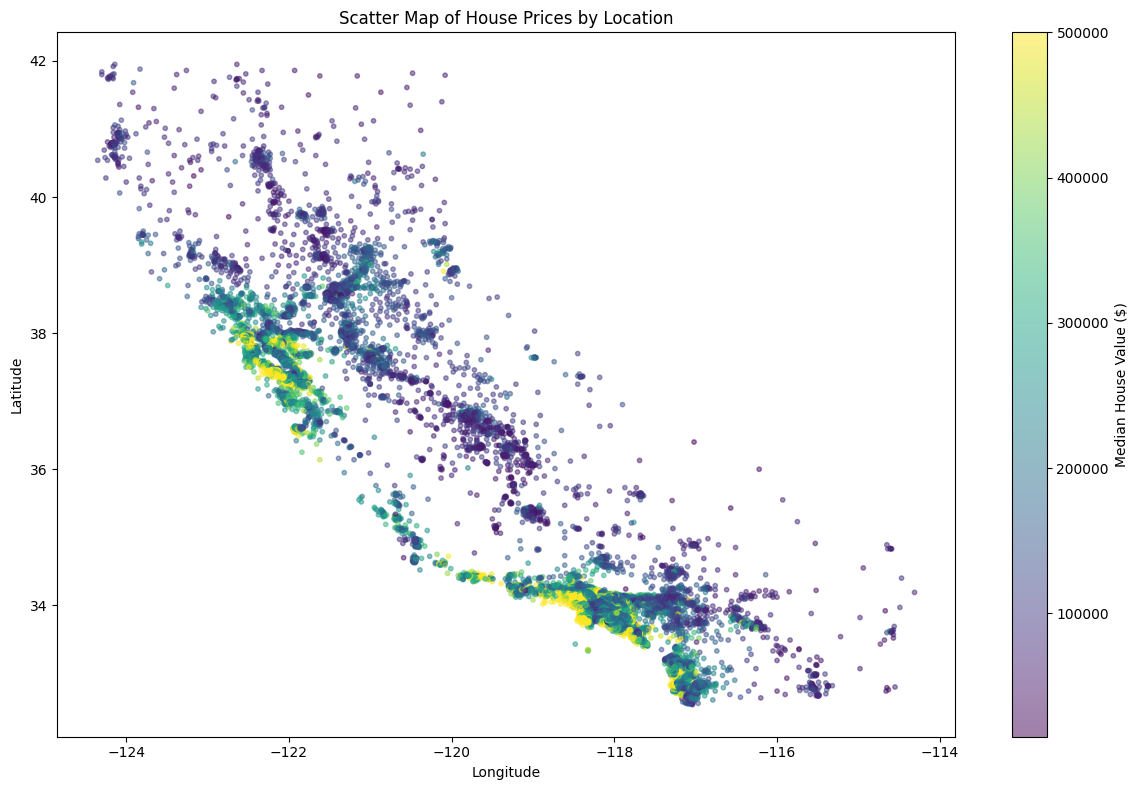

Success on attempt 1

----- Final Code -----
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('housing.csv')

plt.figure(figsize=(12, 8))
scatter = plt.scatter(df['longitude'], df['latitude'], 
                      c=df['median_house_value'], 
                      cmap='viridis', 
                      alpha=0.5, 
                      s=10)
plt.colorbar(scatter, label='Median House Value ($)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Scatter Map of House Prices by Location')
plt.tight_layout()
plt.show()
Result: Success | Attempts: 1

Running task 15: [hard] Handle missing values, encode categorical columns if any, train a linear regression model to predict house prices, and output RMSE and R-squared score
Dataset shape: (20640, 10)

First few rows:
   longitude  latitude  housing_median_age  total_rooms  total_bedrooms  \
0    -122.23     37.88                41.0        880.0           129.0   
1    -122.22     37.86                21.0       

<string>:24: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.




In [9]:
import json
import pandas as pd

# Load benchmark tasks
with open('benchmarks/prompts.json', 'r') as f:
    benchmarks = json.load(f)['benchmarks']

# Dataset path mapping
dataset_paths = {
    "Iris.csv": "Iris.csv",
    "titanic.csv": "titanic.csv",
    "housing.csv": "housing.csv"
}

# Run all benchmark tasks with self-healing pipeline
results = []

for task in benchmarks:
    print(f"\nRunning task {task['id']}: [{task['difficulty']}] {task['prompt']}")

    dataset_path = dataset_paths[task['dataset']]
    result = run_pipeline(task['prompt'], dataset_path)

    results.append({
        "id": task['id'],
        "dataset": task['dataset'],
        "difficulty": task['difficulty'],
        "category": task['category'],
        "prompt": task['prompt'],
        "success": result['success'],
        "attempts": result['attempts']
    })

    print(f"Result: {'Success' if result['success'] else 'Failed'} | Attempts: {result['attempts']}")

# Save results to a DataFrame and display summary
df_results = pd.DataFrame(results)
print("\n===== BENCHMARK RESULTS =====")
print(df_results[['id', 'difficulty', 'category', 'success', 'attempts']])
print(f"\nOverall success rate: {df_results['success'].mean()*100:.1f}%")
print(f"Easy success rate: {df_results[df_results['difficulty']=='easy']['success'].mean()*100:.1f}%")
print(f"Medium success rate: {df_results[df_results['difficulty']=='medium']['success'].mean()*100:.1f}%")
print(f"Hard success rate: {df_results[df_results['difficulty']=='hard']['success'].mean()*100:.1f}%")

# Save results to CSV
df_results.to_csv('benchmark_results_selfhealing.csv', index=False)
print("\nResults saved to benchmark_results_selfhealing.csv")